In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
from tqdm.auto import tqdm

import numpy as np
import jax
from jax import random, numpy as jnp
import flax.linen as nn
from flax.core import pop
import matplotlib.pyplot as plt
from safetensors.numpy import load_file

from dn_exploration.utils import save_state
from visturing.properties.utils import evaluate_all, build_evaluation_table

/media/disk/users/vitojor/dn_exploration/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
path = "/media/disk/vista/Papers/A_Perceptnet"

In [4]:
path_a = "/media/disk/vista/Papers/A_back_to_vista/A_modelo_parametrico"
path_visturing = "/media/disk/users/vitojor/visturing/Data"

In [5]:
class Model(nn.Module):
    @nn.compact
    def __call__(self, inputs, **kwargs):
        outputs = nn.Conv(features=3, kernel_size=(3,3))(inputs)
        outputs = nn.relu(outputs)
        outputs = nn.max_pool(outputs, (2,2), (2,2))
        outputs = nn.Conv(features=6, kernel_size=(3,3))(inputs)
        outputs = nn.relu(outputs)
        outputs = nn.max_pool(outputs, (2,2), (2,2))
        return outputs

In [6]:
# class Model(nn.Module):
#     @nn.compact
#     def __call__(self, inputs, **kwargs):
#         outputs = nn.Conv(features=3, kernel_size=(5,5))(inputs)
#         return outputs

In [7]:
key = random.PRNGKey(42)
x = jnp.ones((1,128,128,3))
model = Model()
variables = model.init(key, x)
state, params = pop(variables, "params")
_, state = model.apply({"params": params, **state}, x, train=True, mutable=list(state.keys()))

In [8]:
save_state(params, "params_csf_init_simple_2")

## Visturing

In [9]:
def calculate_diffs(a, b):
    # a = a/255.
    # b = b/255.
    pred_a = model.apply({"params": params, **state}, a)
    pred_b = model.apply({"params": params, **state}, b)
    return ((pred_a-pred_b)**2).mean(axis=(1,2,3))**(1/2)

In [10]:
results = evaluate_all(
    calculate_diffs,
    data_path=path_visturing,
    gt_path=os.path.join(path_visturing, "ground_truth"),
)

prop1 done
prop2 done
prop3_4 done


/media/disk/users/vitojor/dn_exploration/.venv/lib/python3.10/site-packages/visturing/properties/prop5.py:82: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pearson_corr, p_value_pearson = pearsonr(diffs_stack.ravel(), ds.ravel())


prop5 done
prop6_7 done
prop8 done
prop9 done
prop10 done


In [11]:
table_results = build_evaluation_table(results)
table_results

,Property,RMSE fit (ρ_p),Curve Order (ρ_k)
0,Prop. 1,-0.09,-
1,Prop. 2 achrom.,0.97,0.19
2,Prop. 2 chrom.,0.83,RG: 1.00 | YB: 1.00
3,Prop. 3 & 4,-0.64,-0.57
4,Prop. 5,-,-0.62
5,Prop. 6 & 7,0.49,A: 0.23 | RG: -0.30 | YB: 0.59
6,Prop. 8,0.92,Low f: -0.85 | High f: -0.46
7,Prop. 9,0.92,Low f: -0.69 | High f: -0.97
8,Prop. 10,0.92,Low f: 0.01 | High f: -0.62


In [12]:
import re
numbers = []
for e in table_results.to_numpy().ravel():
    a = re.findall("[-+]?\d+\.\d+", e)
    if len(a) > 0:
        for n in a:
            numbers.append(float(n))
np.mean(numbers), np.median(numbers)

(np.float64(0.10272727272727272), np.float64(0.1))

In [13]:
# from visturing.properties.jax import prop1 as prop
from visturing.properties.jax import prop3_4 as prop
# from visturing.properties.jax import prop2 as prop

In [14]:
def train_step(params):
    def loss_fn(params):
        def calculate_diffs(a, b):
            # a = a/255.
            # b = b/255.
            pred_a = model.apply({"params": params, **state}, a)
            pred_b = model.apply({"params": params, **state}, b)
            return ((pred_a-pred_b)**2).mean(axis=(1,2,3))
        results = prop.evaluate(
            calculate_diffs,
            data_path=os.path.join(path_visturing, "Experiment_3_4"),
            gt_path=os.path.join(path_visturing, "ground_truth"),
        )
        return -results["correlations"]["pearson"]
        # return -results["correlations"]["pearson_achrom"]
        # return -results["correlations"]["kendall"]["achrom"]["kendall"]
        # return -results["correlations"]["kendall"]["kendall"]
    loss, grad = jax.value_and_grad(loss_fn)(params)
    params = jax.tree_util.tree_map(lambda x,g: x-lr*g, params, grad)
    # Train only the first layer
    # params["GDNGamma_0"] = jax.tree_util.tree_map(lambda x,g: x-lr*g, params["GDNGamma_0"], grad["GDNGamma_0"])

    return params, loss, grad

In [15]:
# from jax import config
# config.update("jax_debug_nans", True)

In [16]:
lr = 0.01
epochs = 500
losses = []
for epoch in range(epochs):
    params, loss, grad = train_step(params)
    losses.append(loss)
    print(loss)
    # break

0.5733163
0.56977224
0.5661544
0.5624574
0.5586757
0.55480415
0.55083793
0.54676974
0.5425924
0.53829974
0.5338849
0.5293392
0.5246559
0.51982355
0.51483476
0.5096809
0.5043497
0.4988348
0.4931249
0.48721233
0.48108634
0.47473937
0.46816468
0.46135527
0.45430604
0.44701764
0.43948305
0.43171054
0.4237001
0.415462
0.40700454
0.39834243
0.38949442
0.38047534
0.37130946
0.36202136
0.35263717
0.34318423
0.33368897
0.32418045
0.31468493
0.3052264
0.29583162
0.28652003
0.2773126
0.2682262
0.25927946
0.25047827
0.24183579
0.23336132
0.22505817
0.21693057
0.20898029
0.20120881
0.19361304
0.18619227
0.17894137
0.171858
0.1649395
0.15818053
0.15157303
0.14511539
0.1387976
0.13261934
0.1265733
0.120651685
0.11485067
0.10916224
0.103582285
0.098098345
0.09271108
0.087411255
0.082193226
0.07705213
0.07197846
0.06696966
0.06202103
0.057125125
0.052276094
0.0474753
0.042708434
0.037976936
0.033273328
0.028596152
0.023940237
0.01929992
0.014668893
0.010043427
0.0054213125
0.00079828897
-0.0038336928
-

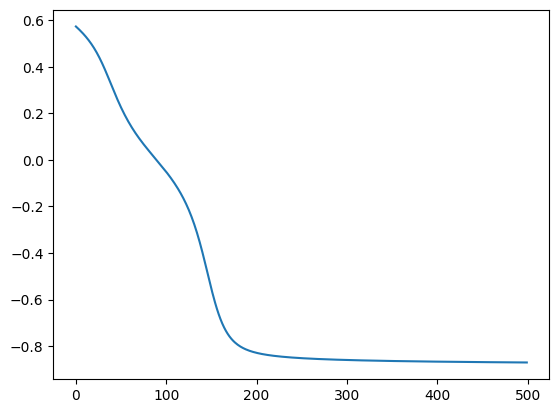

In [17]:
plt.plot(losses)
plt.show()

In [18]:
def calculate_diffs(a, b):
    # a = a/255.
    # b = b/255.
    pred_a, _ = model.apply({"params": params, **state}, a, train=True, mutable=list(state.keys()))
    pred_b, _ = model.apply({"params": params, **state}, b, train=True, mutable=list(state.keys()))
    return ((pred_a-pred_b)**2).mean(axis=(1,2,3))**(1/2)

results = prop.evaluate(
    calculate_diffs,
    data_path=os.path.join(path_visturing, "Experiment_3_4"),
    gt_path=os.path.join(path_visturing, "ground_truth"),
)

In [19]:
results["diffs_s"].shape

(3, 40)

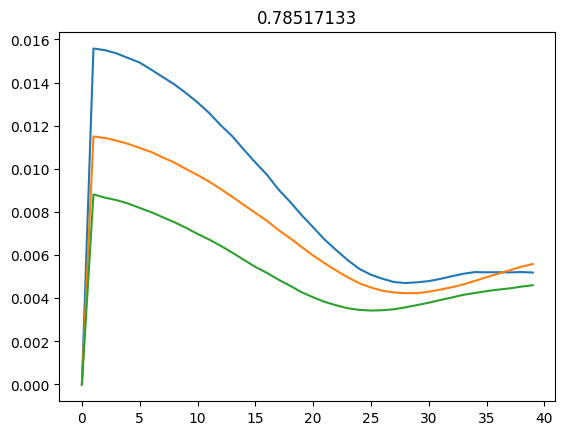

In [20]:
for d in results["diffs_s"]:
    plt.plot(d)
plt.title(results["correlations"]["pearson"])
plt.show()

In [21]:
path_visturing = "/media/disk/users/vitojor/visturing/Data"

In [22]:
def calculate_diffs(a, b):
    # a = a/255.
    # b = b/255.
    pred_a = model.apply({"params": params, **state}, a)
    pred_b = model.apply({"params": params, **state}, b)
    return ((pred_a-pred_b)**2).mean(axis=(1,2,3))**(1/2)

In [23]:
results = evaluate_all(
    calculate_diffs,
    data_path=path_visturing,
    gt_path=os.path.join(path_visturing, "ground_truth"),
)

prop1 done
prop2 done
prop3_4 done


/media/disk/users/vitojor/dn_exploration/.venv/lib/python3.10/site-packages/visturing/properties/prop5.py:82: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pearson_corr, p_value_pearson = pearsonr(diffs_stack.ravel(), ds.ravel())


prop5 done
prop6_7 done
prop8 done
prop9 done
prop10 done


In [24]:
table_results = build_evaluation_table(results)
table_results

,Property,RMSE fit (ρ_p),Curve Order (ρ_k)
0,Prop. 1,0.63,-
1,Prop. 2 achrom.,0.97,0.53
2,Prop. 2 chrom.,0.86,RG: 1.00 | YB: 1.00
3,Prop. 3 & 4,0.79,0.87
4,Prop. 5,-,-0.62
5,Prop. 6 & 7,0.66,A: 0.26 | RG: 1.00 | YB: 0.44
6,Prop. 8,0.93,Low f: -0.84 | High f: -0.40
7,Prop. 9,0.93,Low f: -0.68 | High f: -0.97
8,Prop. 10,0.93,Low f: 0.01 | High f: -0.66


In [25]:
import re
numbers = []
for e in table_results.to_numpy().ravel():
    a = re.findall("[-+]?\d+\.\d+", e)
    if len(a) > 0:
        for n in a:
            numbers.append(float(n))
np.mean(numbers), np.median(numbers)

(np.float64(0.3472727272727273), np.float64(0.645))

In [26]:
save_state(params, "params_csf_trained_simple_2")